In [151]:
#import all necessary libraries for data loading, visualization , prepocressing, model building, and evalution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [140]:
df = pd.read_csv(r"E:\DATA sCIENCE\Data set\monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [118]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [119]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m') # year-month
df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


 Assignment Tasks

1.	Exploratory Data Analysis (EDA)

o	Visualize trends, seasonality, and anomalies in the milk production data.


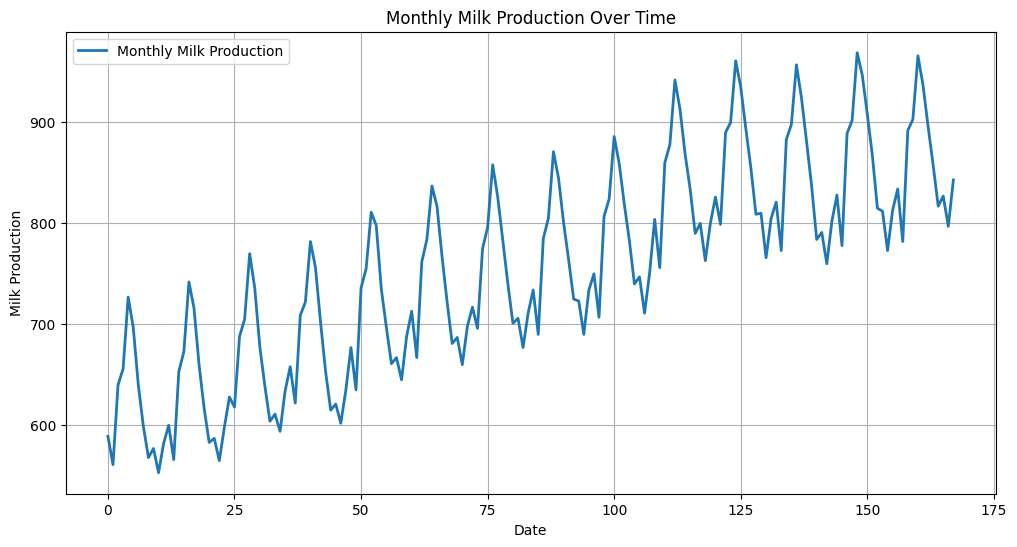

In [120]:
# plot the monthly based trends
plt.figure(figsize=(12,6))
plt.plot(df['Production'], label='Monthly Milk Production', linewidth =2)
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()


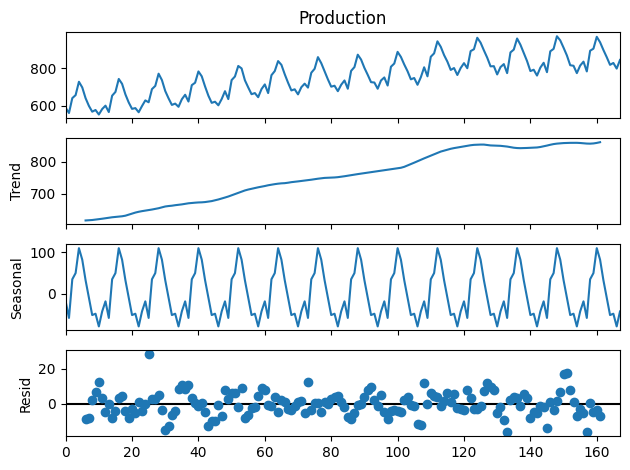

In [121]:
# plot the seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df['Production'], model='additive', period=12)
decomposition.plot()
plt.show()

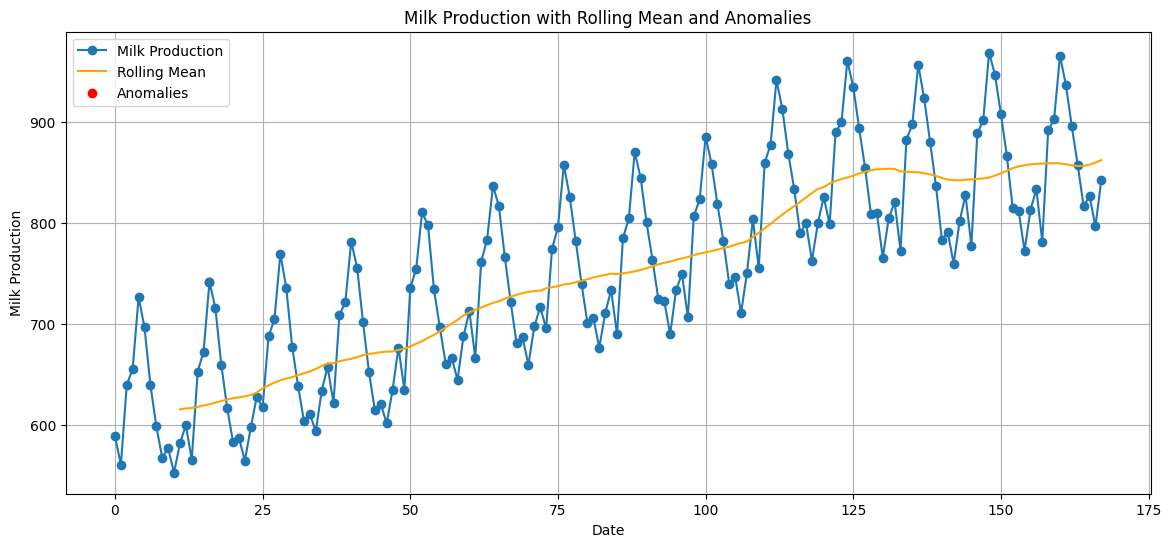

In [122]:
# plot anomalies
rolling_mean = df['Production'].rolling(window=12).mean()
rolling_std = df['Production'].rolling(window=12).std()

anomalies = df[np.abs(df['Production'] - rolling_mean) > 2*rolling_std]

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Production'], label='Milk Production', marker='o')
plt.plot(df.index, rolling_mean, color='orange', label='Rolling Mean')
plt.scatter(anomalies.index, anomalies['Production'], color='red', label='Anomalies')
plt.title('Milk Production with Rolling Mean and Anomalies')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()


In [123]:
#o	Check for any missing values or outliers.
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [124]:
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Production'] < lower_bound) | (df['Production'] > upper_bound)]

print("Number of outliers:", len(outliers))
print("Outlier values:\n", outliers)


Number of outliers: 0
Outlier values:
 Empty DataFrame
Columns: [Date, Production]
Index: []


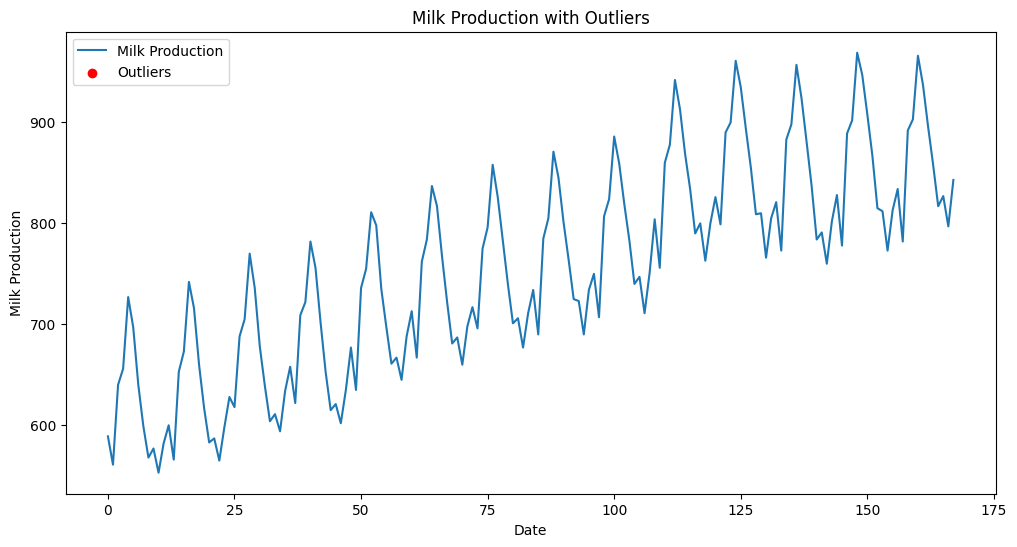

In [125]:
# outlier detection
plt.figure(figsize=(12,6))
plt.plot(df['Production'], label='Milk Production')
plt.scatter(outliers.index, outliers['Production'], color='red', label='Outliers')
plt.title('Milk Production with Outliers')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.show()


In [141]:
#o	Normalize or scale the data for neural network models.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler_data = scaler.fit_transform(df[['Production']])

2.	Data Preparation for Deep Learning

o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.


In [142]:

def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)
    
window_size = 12 #last 12 month -> predict next month
X, y = create_sequences(scaler_data, window_size)

In [143]:
#Split data into training, validation, and test sets.

train_size = int(len(X) * 0.8) # 80 % for train and 20% for test
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [144]:
#Reshape data for model input dimensions.

X_train = X_train.reshape((X_train.shape[0],X_train.shape[1],1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1],1))


3.	Model Building

o	Build three separate models:
    Basic RNN
    LSTM
	GRU


In [145]:
# bulid RNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(64, activation='tanh', input_shape=(window_size, 1)))
model_rnn.add(Dense(1))

#compile model
model_rnn.compile(optimizer='adam', loss='mse')

#train model
history = model_rnn.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50


C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.1779 - val_loss: 0.0199
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0264 - val_loss: 0.1136
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0139 - val_loss: 0.0167
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0093 - val_loss: 0.0063
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045 - val_loss: 0.0339
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0038 - val_loss: 0.0248
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0025 - val_loss: 0.0109
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0024 - val_loss: 0.0158
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0018 - val_loss: 0.0180
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0016 - val_loss: 0.0145
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0015 - val_loss: 0.0123
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0014 - val_loss: 0.0150
Epoch 13/50


In [147]:
# bulid LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='tanh', input_shape=(window_size, 1)))
lstm_model.add(Dense(1))

#compile model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

#train model
history = lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.1162 - val_loss: 0.1382
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0343 - val_loss: 0.0263
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0326 - val_loss: 0.0258
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0252 - val_loss: 0.0467
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0258 - val_loss: 0.0503
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0245 - val_loss: 0.0348
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0236 - val_loss: 0.0285
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0230 - val_loss: 0.0376
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0231 - val_loss: 0.0381
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0224 - val_loss: 0.0296
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0224 - val_loss: 0.0283
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0217 - val_loss: 0.0317
E

In [148]:
#bulid GRU model
gru_model = Sequential()
gru_model.add(GRU(50, activation='tanh', input_shape=(window_size, 1)))
gru_model.add(Dense(1))

#compile model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

#train model
history = gru_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.1372 - val_loss: 0.2247
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0454 - val_loss: 0.0560
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0238 - val_loss: 0.0215
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0294 - val_loss: 0.0284
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0222 - val_loss: 0.0486
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0214 - val_loss: 0.0532
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0213 - val_loss: 0.0442
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0204 - val_loss: 0.0357
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0198 - val_loss: 0.0391
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0193 - val_loss: 0.0362
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0190 - val_loss: 0.0379
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0185 - val_loss: 0.0368
E

In [149]:
#prediction for each model
pred_rnn = model_rnn.predict(X_test)
pred_lstm = lstm_model.predict(X_test)
pred_gru = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step


4.	Model Evaluation

o	Plot predictions vs. actual values.


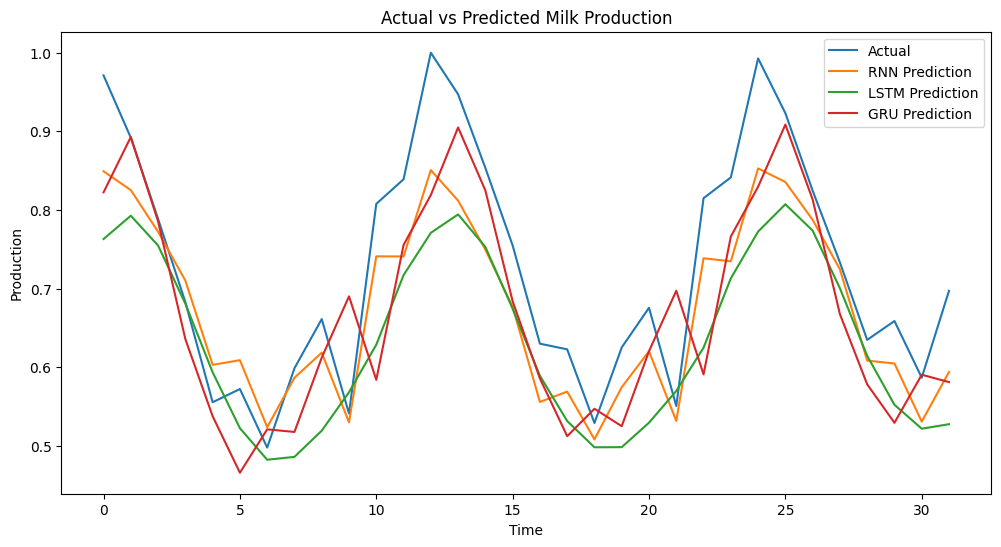

In [150]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(pred_rnn, label='RNN Prediction')
plt.plot(pred_lstm, label='LSTM Prediction')
plt.plot(pred_gru, label='GRU Prediction')

plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.show()


In [152]:
#Calculate forecasting metrics: RMSE, MAE, MAPE.

pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)
pred_gru = scaler.inverse_transform(pred_gru)
y_test_actual = scaler.inverse_transform(y_test)

In [153]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred )/y_true))*100
    return rmse, mae ,mape

print("RNN:", evaluate(y_test_actual, pred_rnn))
print("LSTM:", evaluate(y_test_actual, pred_lstm))
print("GRU:", evaluate(y_test_actual, pred_gru))


RNN: (np.float64(30.895014993287575), 26.129705429077145, np.float64(2.9636137465976495))
LSTM: (np.float64(48.973771014839414), 40.925575256347656, np.float64(4.654100332899723))
GRU: (np.float64(42.57668617295824), 33.70308876037598, np.float64(3.9174527252892806))


#Compare the performance of RNN, LSTM, and GRU.

Based on the results, the RNN model gives the most accurate predictions for monthly milk production. It has the lowest RMSE, MAE, and MAPE, which means its forecasts are closest to the real values.

The GRU model performs fairly well, but not as good as RNN.

The LSTM model shows the highest errors because the dataset is small and the patterns are not very complex—LSTM usually works better with larger datasets.

5.	Prediction and Visualization

Forecast milk production for the next 12 months.
Visualize the predicted trend with uncertainty or confidence intervals if possible


In [155]:
# Predict future 12 months
future_preds = []

last_sequence = scaler_data[-window_size:]   # last 12 months data

current_seq = last_sequence.reshape(1, window_size, 1)

for i in range(12):
    next_pred = model_rnn.predict(current_seq)[0][0]
    future_preds.append(next_pred)

    current_seq = np.append(current_seq[:,1:,:], [[[next_pred]]], axis=1) # this updated sequences become the input for the next prediction

#reverse scale
future_preds_actual = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
print(future_preds_actual)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[815.74567]
 [781.047  ]
 [862.0593 ]
 [859.95953]
 [908.52246]
 [897.33356]
 [874.3466 ]
 [849.908  ]
 [813.41797]
 [824.018  ]
 [795.94324]
 [828.8736 ]]


6.	Business Insights
  
o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

->  